# Is the store booming and the web collapsing, as Marketing says?

**Week 2, Monday. The second case, in pairs or alone.** It runs in the take-home.

> "The same numbers for every channel: app, web and store. Marketing says the store is booming
> and the web is collapsing, and wants the budget moved. Is that what the book says?"
> Anand Iyer, finance controller, Kalpa Retail

**The situation.** Kalpa sells through three channels: its app, its website and its stores.
Booked revenue, every order at its amount, was Rs 10,00,00,000 in Q1 (April to June 2026) and
Rs 9,84,00,000 in Q2 (July to September 2026). Business, the corporate segment, buys for
companies, and its orders are worth lakhs each; Kalpa's consumers buy for themselves, and their
orders are worth hundreds or a few thousand rupees. Marketing read the channel totals and wants
budget moved from the web to the stores.

**This is the solution.** Every marker is filled with its key and the notebook runs clean from the
top; the reasons for each key are at the end.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import re
from decimal import Decimal
SQL_DIR = kit.data_dir().parent / "sql"

def blocks(stem):
    """Every named block of a .sql file in ../sql/, keyed by the name on its '-- name:' line."""
    text = (SQL_DIR / f"C2_W02_D01_{stem}_STUDENT.sql").read_text(encoding="utf-8")
    parts = re.split(r"^-- name: (\w+)\s*$", text, flags=re.M)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

def statements(block):
    """A block's statements with its comment lines removed, for a block that runs several."""
    bare = "\n".join(l for l in block.splitlines() if not l.strip().startswith("--"))
    return [s.strip() for s in bare.split(";") if s.strip()]

def num(v):
    """A database number as a Python int or float."""
    if isinstance(v, Decimal):
        return int(v) if v == v.to_integral_value() else float(v)
    return v

def show(rows, caption="", money=(), limit=12):
    """Rows from kit.sql as the kit's table, with the columns named in money set in rupees."""
    if not rows:
        kit.table(["result"], [["no rows"]], caption)
        return
    heads = list(rows[0])
    def cell(h, v):
        v = num(v)
        if v is None:
            return "NULL"
        if h in money:
            return kit.rupees(v)
        return f"{v:,}" if isinstance(v, int) and abs(v) >= 10000 else str(v)
    body = [[cell(h, r[h]) for h in heads] for r in rows[:limit]]
    if len(rows) > limit:
        body.append(["..." for _ in heads])
    kit.table(heads, body, caption)

def run(name, caption="", money=(), limit=12):
    """Print a named block, run it, show its rows and hand them back."""
    print(Q[name])
    rows = kit.sql(Q[name])
    show(rows, caption, money, limit)
    return rows

def pct(before, after):
    """The change from before to after, in percent."""
    return 100 * (float(after) - float(before)) / float(before)

def rows(query):
    """Run a query and hand back its rows with every number as a Python number."""
    return [{k: num(v) for k, v in r.items()} for r in kit.sql(query)]
print("connected:", kit.sql("select version()")[0]["version"].split(",")[0])

connected: PostgreSQL 16.14 (Ubuntu 16.14-0ubuntu0.24.04.1) on x86_64-pc-linux-gnu


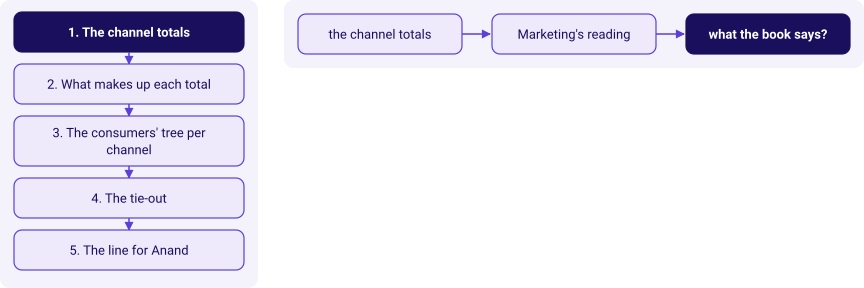

In [2]:
kit.side_by_side(
    kit.ladder(["The channel totals", "What makes up each total", "The consumers' tree per channel",
                "The tie-out", "The line for Anand"], lit=0, show=False),
    kit.flow(["the channel totals", "Marketing's reading", "what the book says?"],
             kinds=["plain", "plain", "lit"], show=False),
)

## Step 1. What do the channel totals say from Q1 to Q2?

Where this is used at work: a channel manager's budget follows the channel's total, so the
total is the first number anyone reads.

channel,quarter,orders,revenue
app,Q1,192,"Rs 4,21,38,840"
app,Q2,153,"Rs 4,25,90,270"
store,Q1,165,"Rs 1,99,59,110"
store,Q2,159,"Rs 3,21,48,730"
web,Q1,181,"Rs 3,79,02,050"
web,Q2,150,"Rs 2,36,61,000"


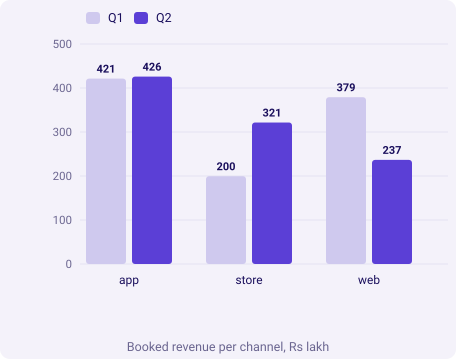

In [3]:
# TODO 1. Which grouping, with the same columns in the SELECT, gives Anand one line per channel and quarter?
#   a) GROUP BY channel
#   b) GROUP BY quarter
#   c) GROUP BY channel, quarter, status
#   d) GROUP BY channel, quarter
GROUPING = {"a": "channel", "b": "quarter", "c": "channel, quarter, status", "d": "channel, quarter"}["d"]
lines = rows(f"SELECT {GROUPING}, count(*) AS orders, sum(amount) AS revenue FROM orders "
             f"GROUP BY {GROUPING} ORDER BY {GROUPING}")
show(lines, "The lines this grouping gives Anand", money=("revenue",))
pairs = rows("SELECT DISTINCT channel, quarter FROM orders")
kit.check("the lines cover each channel in each quarter, once each",
          all("channel" in r and "quarter" in r for r in lines) and len(lines) == len(pairs)
          and {(r["channel"], r["quarter"]) for r in lines} == {(p["channel"], p["quarter"]) for p in pairs},
          f"{len(lines)} lines against {len(pairs)} channel-quarters")

totals = rows("SELECT channel, quarter, count(*) AS orders, sum(amount) AS revenue FROM orders "
              "GROUP BY channel, quarter ORDER BY 1, 2")
t = {(r["channel"], r["quarter"]): r for r in totals}
channels = sorted({r["channel"] for r in totals})
kit.columns(channels, [(q, [t[(c, q)]["revenue"] / 1e5 for c in channels]) for q in ("Q1", "Q2")],
            title="Booked revenue per channel, Rs lakh", fmt=lambda v: f"{v:,.0f}")

In [4]:
kit.check("the channels add back to the book in each quarter",
          sum(t[(c, "Q1")]["revenue"] for c in channels) == 100000000
          and sum(t[(c, "Q2")]["revenue"] for c in channels) == 98400000)

## Step 2. Which orders make up each channel's total?

Where this is used at work: a total made of a few very large orders and many small ones is two
businesses, and each is read on its own before the total is.

Kalpa's sales ledger books the app's Business revenue at Rs 4,17,78,440 in Q1 and Rs 4,23,16,600
in Q2. The check after marker 2 sets the app's Business side, as your label draws it, beside
those two numbers.

In [5]:
# TODO 2. Which label puts every Business order, and no consumer order, on the Business side, next quarter as well?
#   a) Business where the customer's segment is Business, consumer for the other three
#   b) The customer's own segment name, four labels in each channel
#   c) Business where the order is worth more than Rs 5,00,000, and consumer where it is not
#   d) Business where the customer is in Business or Retail-Plus, the segments with larger orders
KIND = {"a": "CASE WHEN c.segment = 'Business' THEN 'Business' ELSE 'consumer' END", "b": "c.segment",
        "c": "CASE WHEN o.amount > 500000 THEN 'Business' ELSE 'consumer' END",
        "d": "CASE WHEN c.segment IN ('Business', 'Retail-Plus') THEN 'Business' ELSE 'consumer' END"}["a"]
split = rows(f"""SELECT o.channel, {KIND} AS kind, o.quarter, count(*) AS orders,
                        count(DISTINCT o.customer_id) AS customers, sum(o.amount) AS revenue
                 FROM orders o JOIN customers c USING (customer_id)
                 GROUP BY 1, 2, 3 ORDER BY 1, 2, 3""")
show(split, "Each channel, Business and consumers apart", money=("revenue",))

channel,kind,quarter,orders,customers,revenue
app,Business,Q1,31,22,"Rs 4,17,78,440"
app,Business,Q2,29,23,"Rs 4,23,16,600"
app,consumer,Q1,161,111,"Rs 3,60,400"
app,consumer,Q2,124,101,"Rs 2,73,670"
store,Business,Q1,24,20,"Rs 1,96,33,000"
store,Business,Q2,32,22,"Rs 3,18,84,000"
store,consumer,Q1,141,108,"Rs 3,26,110"
store,consumer,Q2,127,99,"Rs 2,64,730"
web,Business,Q1,42,24,"Rs 3,76,03,000"
web,Business,Q2,30,19,"Rs 2,33,84,000"


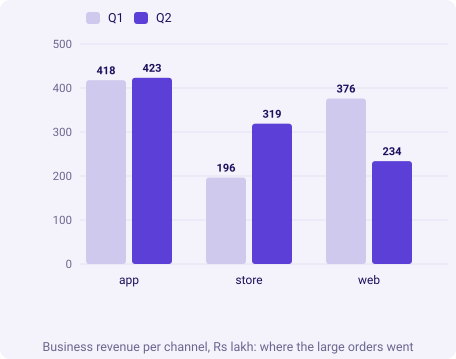

In [6]:
kinds = {r["kind"] for r in split}
biz = {(r["channel"], r["quarter"]): r["revenue"] for r in split if r["kind"] == "Business"}
if biz:
    kit.columns(channels, [(q, [biz.get((c, q), 0) / 1e5 for c in channels]) for q in ("Q1", "Q2")],
                title="Business revenue per channel, Rs lakh: where the large orders went", fmt=lambda v: f"{v:,.0f}")
kit.check("every order is labelled one of two kinds", len(kinds) == 2, ", ".join(sorted(kinds)))
LEDGER_APP_BUSINESS = {"Q1": 41778440, "Q2": 42316600}  # the sales ledger's app Business revenue
app_side = {q: biz.get(("app", q), 0) for q in ("Q1", "Q2")}
kit.check("the app's Business side matches the sales ledger in both quarters", app_side == LEDGER_APP_BUSINESS,
          f"{kit.rupees(app_side['Q1'])} and {kit.rupees(app_side['Q2'])} on your Business side")
kit.check("the two kinds add back to each channel's total",
          all(sum(r["revenue"] for r in split if r["channel"] == c and r["quarter"] == q) == t[(c, q)]["revenue"]
              for c in channels for q in ("Q1", "Q2")))

## Step 3. How did each channel's consumers move, branch by branch?

Where this is used at work: a channel's consumer health is its consumers' tree, customers times
orders each times revenue per order, read as a change.

channel,quarter,orders,customers,orders_per_customer,revenue
app,Q1,161,111,1.45,"Rs 3,60,400"
app,Q2,124,101,1.23,"Rs 2,73,670"
store,Q1,141,108,1.31,"Rs 3,26,110"
store,Q2,127,99,1.28,"Rs 2,64,730"
web,Q1,139,106,1.31,"Rs 2,99,050"
web,Q2,120,94,1.28,"Rs 2,77,000"


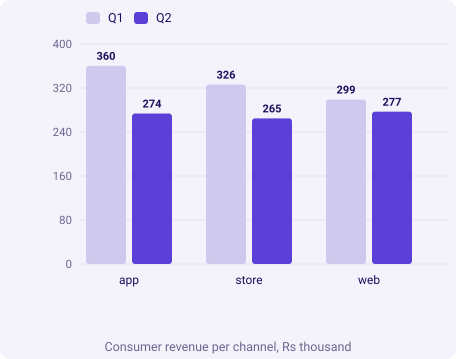

In [7]:
# TODO 3. Which expression counts each channel's consumers, each once?
#   a) count(*), since each consumer order row belongs to a consumer
#   b) sum(1), since adding one per order reaches everyone who bought
#   c) count(DISTINCT o.customer_id), since an id stands for one consumer
#   d) count(o.customer_id), since it counts the customer column rather than rows
CUST = {"a": "count(*)", "b": "sum(1)", "c": "count(DISTINCT o.customer_id)",
        "d": "count(o.customer_id)"}["c"]

# TODO 4. Which orders-per-consumer figure multiplies back to the orders?
#   a) count(*) / count(DISTINCT o.customer_id)
#   b) round(count(*)::numeric / count(DISTINCT o.customer_id), 2)
#   c) round(count(*) / count(DISTINCT o.customer_id), 2)
#   d) round(count(DISTINCT o.customer_id)::numeric / count(*), 2)
FREQ = {"a": "count(*) / {cust}", "b": "round(count(*)::numeric / {cust}, 2)", "c": "round(count(*) / {cust}, 2)",
        "d": "round({cust}::numeric / count(*), 2)"}["b"].format(cust=CUST)
consumers = rows(f"""SELECT o.channel, o.quarter, count(*) AS orders, {CUST} AS customers,
                            {FREQ} AS orders_per_customer, sum(o.amount) AS revenue
                     FROM orders o JOIN customers c USING (customer_id)
                     WHERE c.segment <> 'Business'
                     GROUP BY o.channel, o.quarter ORDER BY 1, 2""")
show(consumers, "Consumers only, per channel and quarter", money=("revenue",))
cons = {(r["channel"], r["quarter"]): r for r in consumers}
kit.columns(channels, [(q, [cons[(c, q)]["revenue"] / 1000 for c in channels]) for q in ("Q1", "Q2")],
            title="Consumer revenue per channel, Rs thousand", fmt=lambda v: f"{v:,.0f}")

In [8]:
kit.check("consumers are fewer than their orders in every row", all(r["customers"] < r["orders"] for r in consumers))
kit.check("every ratio multiplies back to its orders within half an order",
          all(abs(float(r["orders_per_customer"]) * r["customers"] - r["orders"]) < 0.5 for r in consumers))

## Step 4. Which line goes on Anand's channel sheet?

Where this is used at work: the line a budget is moved on has to read the part of the business
the budget is for.

channel,"booked total, Q1 to Q2","consumers only, Q1 to Q2"
app,+1.1%,-24.1%
store,+61.1%,-18.8%
web,-37.6%,-7.4%


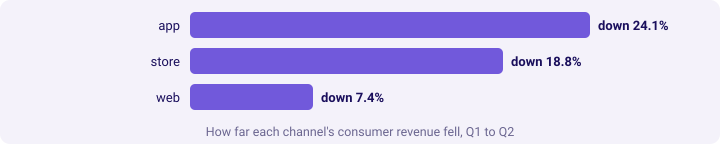

In [9]:
change = {c: pct(cons[(c, "Q1")]["revenue"], cons[(c, "Q2")]["revenue"]) for c in channels}
total_change = {c: pct(t[(c, "Q1")]["revenue"], t[(c, "Q2")]["revenue"]) for c in channels}
kit.table(["channel", "booked total, Q1 to Q2", "consumers only, Q1 to Q2"],
          [(c, f"{total_change[c]:+.1f}%", f"{change[c]:+.1f}%") for c in channels],
          caption="The channel totals beside the consumers' own change")
kit.bars([(c, abs(change[c])) for c in channels], fmt=lambda v: f"down {v:.1f}%",
         title="How far each channel's consumer revenue fell, Q1 to Q2")

# TODO 5. Which channel lost the largest share of its consumer revenue?
#   a) web
#   b) app
#   c) store
#   d) none, since every channel held its consumers
WORST = {"a": "web", "b": "app", "c": "store", "d": None}["b"]

# TODO 6. Which line goes on Anand's sheet for the store?
#   a) Store revenue rose 61.1 percent from Q1 to Q2, so the budget should move to the stores
#   b) The store is flat once the Business orders are removed
#   c) Store consumer revenue rose with its Business orders, so both parts of the store grew
#   d) Store consumer revenue fell; the store total rose on Business orders
LINE = {"a": ("total", 1), "b": ("consumers", 0), "c": ("consumers", 1), "d": ("consumers", -1)}["d"]

# TODO 7. Which fact would move the budget question back to the channel totals?
#   a) If the web's consumer orders fell further next quarter
#   b) If Anand asked for the channels in rupees rather than orders
#   c) If Business chose a channel for that channel's own service
#   d) If Business placed its orders through whichever channel its buyer chose on the day
REASON = {"a": "consumers", "b": "rupees", "c": "service", "d": "chance"}["c"]

In [10]:
fell = [c for c in channels if change[c] < 0]
kit.check("your answer names a channel exactly when some channel's consumer revenue fell",
          (WORST is None) == (not fell), f"{len(fell)} of {len(channels)} channels fell")
kit.check("no channel lost a larger share of its consumer revenue than the one named",
          WORST is None or all(change[WORST] <= v for v in change.values()),
          f"{WORST or 'none'} named; the largest fall was {min(change.values()):+.1f}%")
moved = 1 if change["store"] > 0.05 else -1 if change["store"] < -0.05 else 0
kit.check("the store line reads the store's consumers in the direction they moved",
          LINE == ("consumers", moved), f"the store's consumer revenue moved {change['store']:+.1f}%")
print("Marker 7 asks for a fact the book does not record, why a buyer chose a channel, so no check "
      "settles it here; the solution file gives the reason for its key.")

Marker 7 asks for a fact the book does not record, why a buyer chose a channel, so no check settles it here; the solution file gives the reason for its key.


**Why each key holds.** 1 d gives one line per channel and quarter; a and b lose a dimension, so
each line merges two quarters or three channels, and c splits every line three ways by status,
18 lines. 2 a labels by the customer's segment, so an order a Business customer places lands on
the Business side whatever its size, this quarter and next; b keeps four segments, c labels by
size and calls the 50 Business orders worth Rs 2,09,000 to Rs 4,94,000 consumer orders, so 138
orders carry the Business label instead of 188, and d labels Retail-Plus's 355 orders Business as
well. 3 c counts each consumer once; a, b and d count orders. 4 b divides in `numeric`; a and c
divide integers and d divides the wrong way round. 5 b: app consumer revenue fell 24.1 percent,
against 18.8 for the store and 7.4 for the web; a is the web, whose total fell furthest on
Business orders while its consumers fell least, c is the store, and d says no channel lost
consumer revenue when all three did. 6 d
reads the store's consumers in the direction they moved and names why the total rose; a is
Marketing's reading of the total, b and c are wrong on the direction. 7 c: only if Business chose
a channel for that channel's own service would the channel's total say something about the
channel; a is about consumers and would not move the question, b changes the unit, and d is the
reason the totals mislead.

**Post your answer.** Seven letters, in the order of the markers, and the line you would put on
Anand's channel sheet about Marketing's request, with the number it rests on.

In [11]:
kit.check_summary()